In [3]:
import os
import numpy as np
import json
import pandas as pd

import matplotlib.pyplot as plt


from tigramite import plotting as tp
from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr

from tigramite.models import Models
from tigramite.causal_effects import CausalEffects

def load_run_data(run_folder):
    """
    Load all saved data from a single run into memory.
    
    Parameters
    ----------
    run_folder : str
        Path to the run folder containing the saved data
        
    Returns
    -------
    dict
        Dictionary with all loaded data components
    """
    results = {}
    
    # 1. Load dataset
    print("Loading dataset...")
    data_path = os.path.join(run_folder, "dataset_data.npy")
    metadata_path = os.path.join(run_folder, "dataset_metadata.json")
    
    if os.path.exists(data_path):
        data = np.load(data_path)
        results['data'] = data
        
        # Get variable names and create DataFrame
        var_names = None
        if os.path.exists(metadata_path):
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
                var_names = metadata.get('var_names')
                results['metadata'] = metadata
        
        if var_names is None:
            var_names = [f'X{i+1}' for i in range(data.shape[1])]
        
        # Create Tigramite DataFrame
        dataframe = pp.DataFrame(data, var_names=var_names)
        results['dataframe'] = dataframe
    else:
        print(f"Dataset not found at {data_path}")
    
    # 2. Load discovered graphs
    print("Loading discovered graphs...")
    
    # a. PCMCI graph
    pcmci_graph_path = os.path.join(run_folder, "discovery_pcmci_graph.npy")
    pcmci_val_path = os.path.join(run_folder, "discovery_pcmci_val_matrix.npy")
    
    if os.path.exists(pcmci_graph_path):
        pcmci_graph = np.load(pcmci_graph_path)
        results['pcmci_graph'] = pcmci_graph
        
        if os.path.exists(pcmci_val_path):
            pcmci_val_matrix = np.load(pcmci_val_path)
            results['pcmci_val_matrix'] = pcmci_val_matrix
    else:
        print(f"PCMCI graph not found at {pcmci_graph_path}")
    
    # b. Bagged graph
    bagged_graph_path = os.path.join(run_folder, "discovery_bootstrap_bagged_graph.npy")
    
    if os.path.exists(bagged_graph_path):
        bagged_graph = np.load(bagged_graph_path)
        results['bagged_graph'] = bagged_graph
    else:
        print(f"Bagged graph not found at {bagged_graph_path}")
    
    # c. Bootstrap replica graphs
    boot_graphs_path = os.path.join(run_folder, "discovery_bootstrap_boot_graphs.npy")
    
    if os.path.exists(boot_graphs_path):
        boot_graphs = np.load(boot_graphs_path)
        results['boot_graphs'] = boot_graphs
        results['n_boot_samples'] = boot_graphs.shape[0]
    else:
        print(f"Bootstrap graphs not found at {boot_graphs_path}")
    
    # 3. Load effect estimation results
    print("Loading effect estimation results...")
    
    # Find all effect files
    effect_files = [f for f in os.listdir(run_folder) if f.startswith("effects_") and f.endswith(".json")]
    
    # Group effect files by effect pairs
    effect_pairs = set([f.split("_all.json")[0] for f in effect_files if f.endswith("_all.json")])
    
    results['effects'] = {}
    results['adjustment_sets'] = {}
    
    for effect_pair in effect_pairs:
        # Extract X and Y from effect pair name
        pair_parts = effect_pair.replace("effects_", "").split("_to_")
        if len(pair_parts) == 2:
            x_parts = pair_parts[0].split("_")
            y_parts = pair_parts[1].split("_")
            
            if len(x_parts) == 2 and len(y_parts) == 2:
                X = (int(x_parts[0]), int(x_parts[1]))
                Y = (int(y_parts[0]), int(y_parts[1]))
                
                pair_key = f"{X[0]}_{X[1]}_to_{Y[0]}_{Y[1]}"
                results['effects'][pair_key] = {}
                results['adjustment_sets'][pair_key] = {}
                
                # Load all.json file (summary)
                all_path = os.path.join(run_folder, f"{effect_pair}_all.json")
                if os.path.exists(all_path):
                    with open(all_path, 'r') as f:
                        all_data = json.load(f)
                        results['effects'][pair_key]['all'] = all_data
                
                # Load method-specific files
                for method in ['true_graph', 'pcmci', 'bagged', 'bootstrap']:
                    method_path = os.path.join(run_folder, f"{effect_pair}_{method}.json")
                    if os.path.exists(method_path):
                        with open(method_path, 'r') as f:
                            method_data = json.load(f)
                            results['effects'][pair_key][method] = method_data
                            
                            # Extract adjustment sets if available
                            if 'adjustment_set' in method_data:
                                results['adjustment_sets'][pair_key][method] = method_data['adjustment_set']
    
    # 4. Load timing information
    print("Loading timing information...")
    timing_path = os.path.join(run_folder, "timing_summary.json")
    if os.path.exists(timing_path):
        with open(timing_path, 'r') as f:
            timing_data = json.load(f)
            results['timing'] = timing_data
    
    # 5. Load parameters
    print("Loading parameters...")
    params_path = os.path.join(run_folder, "parameters.json")
    if os.path.exists(params_path):
        with open(params_path, 'r') as f:
            params_data = json.load(f)
            results['parameters'] = params_data
    
    print(f"Successfully loaded data from {run_folder}")
    return results

def summarize_results(results):
    """
    Print a summary of the loaded results
    
    Parameters
    ----------
    results : dict
        Dictionary with loaded results
    """
    print("\n" + "="*50)
    print("RUN SUMMARY")
    print("="*50)
    
    # Data summary
    if 'data' in results:
        data = results['data']
        print(f"Data shape: {data.shape}")
        print(f"Variable names: {results.get('dataframe').var_names}")
    
    # Graph summary
    print("\nGraph Summary:")
    for graph_type in ['pcmci_graph', 'bagged_graph', 'boot_graphs']:
        if graph_type in results:
            if graph_type == 'boot_graphs':
                print(f"  {graph_type}: {results[graph_type].shape[0]} bootstrap samples")
            else:
                print(f"  {graph_type}: Shape {results[graph_type].shape}")
    
    # Effects summary
    if 'effects' in results:
        print("\nEffect Estimates:")
        for pair, effects in results['effects'].items():
            print(f"\n  Effect pair: {pair}")
            
            # Get true effect if available
            true_effect = effects.get('all', {}).get('true_effect', None)
            if true_effect is not None:
                print(f"  True effect: {true_effect:.4f}")
            
            # Method estimates
            for method in ['true_graph_effect', 'pcmci_effect', 'bagged_effect']:
                if method in effects.get('all', {}):
                    estimate = effects['all'][method]
                    if estimate is not None:
                        print(f"  {method}: {estimate:.4f}")
            
            # Bootstrap summary if available
            bootstrap_stats = effects.get('all', {}).get('bootstrap_stats', {})
            if bootstrap_stats:
                print(f"  Bootstrap mean: {bootstrap_stats.get('mean', 'N/A'):.4f}")
                print(f"  Bootstrap 95% CI: [{bootstrap_stats.get('ci_lower', 'N/A'):.4f}, "
                     f"{bootstrap_stats.get('ci_upper', 'N/A'):.4f}]")
    
    # Adjustment sets summary
    if 'adjustment_sets' in results:
        print("\nAdjustment Sets:")
        for pair, adj_sets in results['adjustment_sets'].items():
            print(f"\n  Effect pair: {pair}")
            for method, adj_set in adj_sets.items():
                if adj_set is not None:
                    print(f"  {method}: {adj_set} (size: {len(adj_set)})")
    
    # Parameters summary
    if 'parameters' in results:
        print("\nParameters:")
        for key, value in results['parameters'].items():
            print(f"  {key}: {value}")
    
    print("\n" + "="*50)


Loading dataset...
Loading discovered graphs...
Loading effect estimation results...
Loading timing information...
Loading parameters...
Successfully loaded data from full_study_results_2025-04-03_15-39-17/T_study/T_1000

RUN SUMMARY
Data shape: (1000, 4)
Variable names: ['X1', 'X2', 'X3', 'X4']

Graph Summary:
  pcmci_graph: Shape (4, 4, 5)
  bagged_graph: Shape (4, 4, 5)
  boot_graphs: 200 bootstrap samples

Effect Estimates:

  Effect pair: 0_-2_to_3_0
  True effect: 0.7500
  true_graph_effect: 0.7551
  bagged_effect: 0.7541
  Bootstrap mean: 0.7603
  Bootstrap 95% CI: [0.7589, 0.7617]

Adjustment Sets:

  Effect pair: 0_-2_to_3_0
  true_graph: [[2, -3], [2, -2], [3, -2], [1, -2]] (size: 4)
  bagged: [[2, -2], [3, -2], [2, -3], [1, -5], [1, -2]] (size: 5)

Parameters:
  auto_coeff: 0.5
  cross_coeff: 0.5
  noise_sigma: 1
  n_vars: 4
  T: 1000
  pc_alpha: 0.05
  tau_max: 4
  n_boot: 200
  seed: None
  effect_pairs: [[[0, -2], [3, 0]]]
  timestamp: 2025-04-03_20-09-03



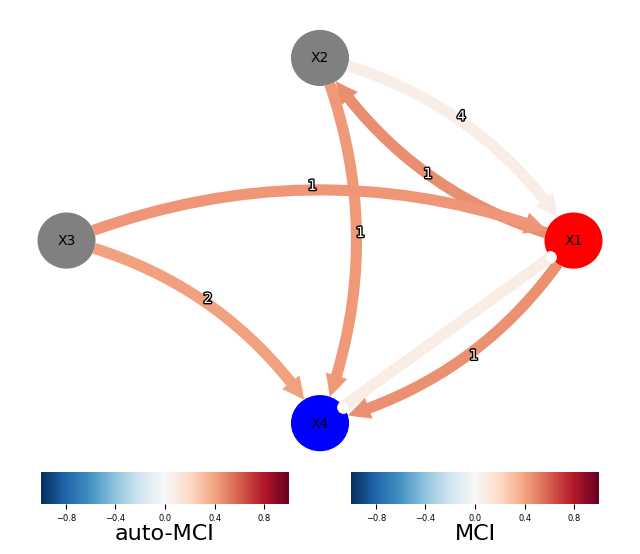

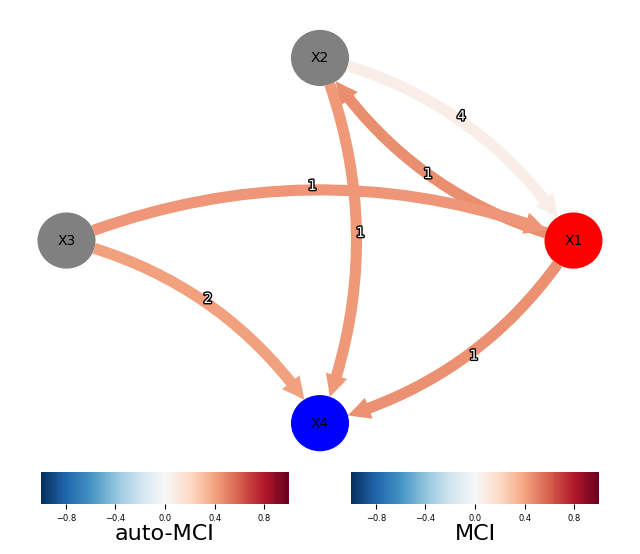

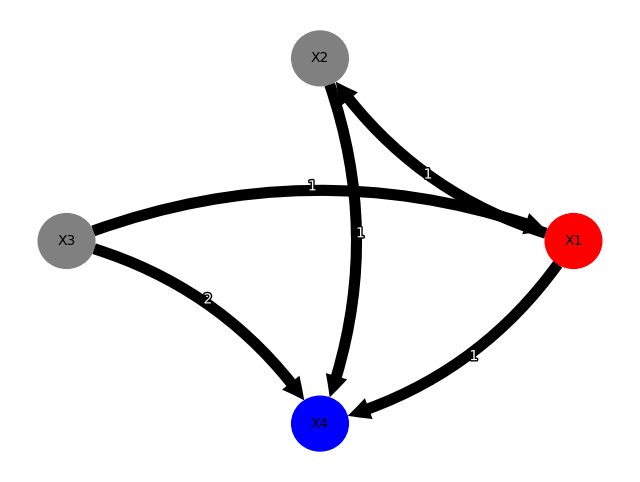

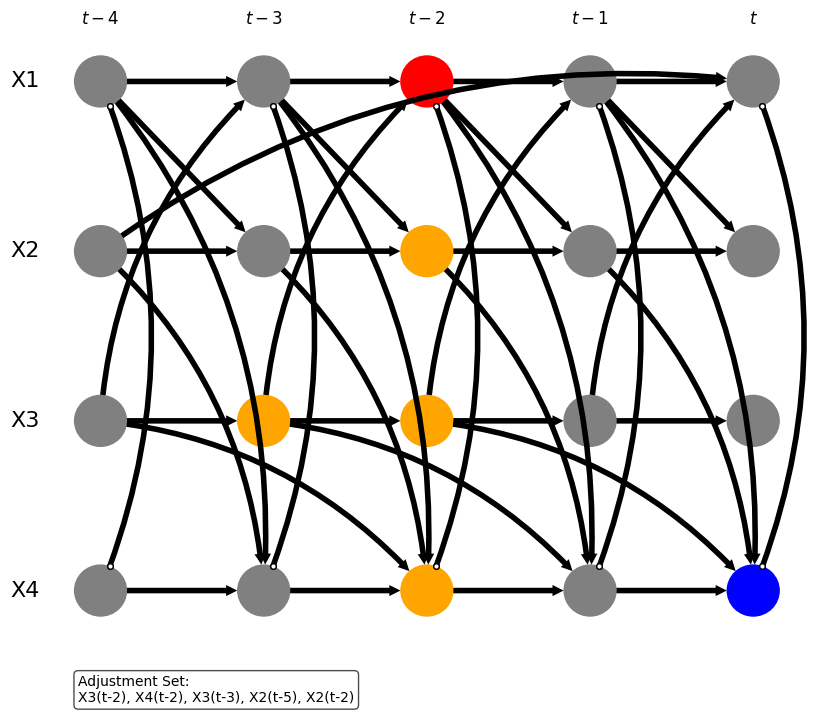

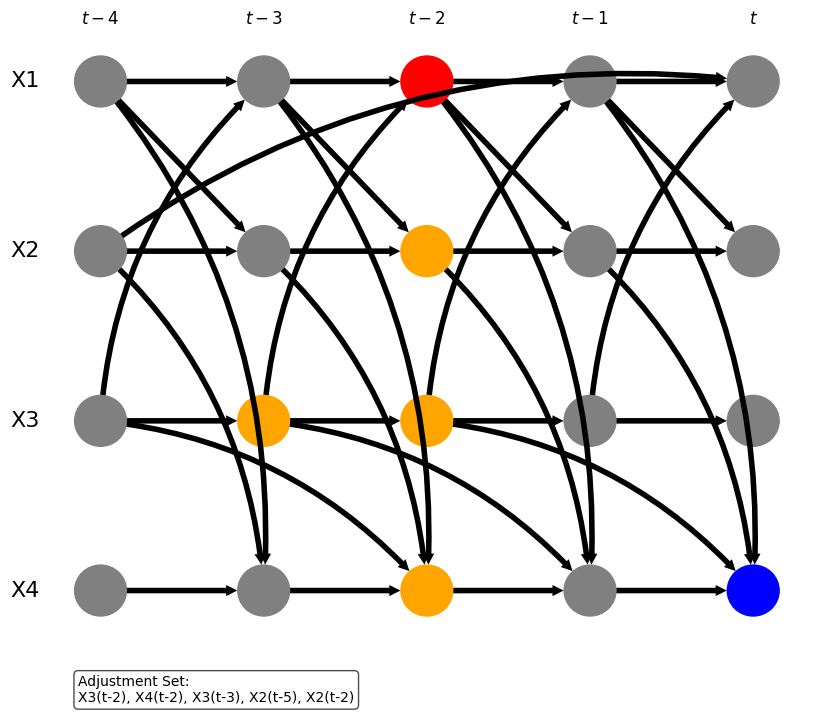

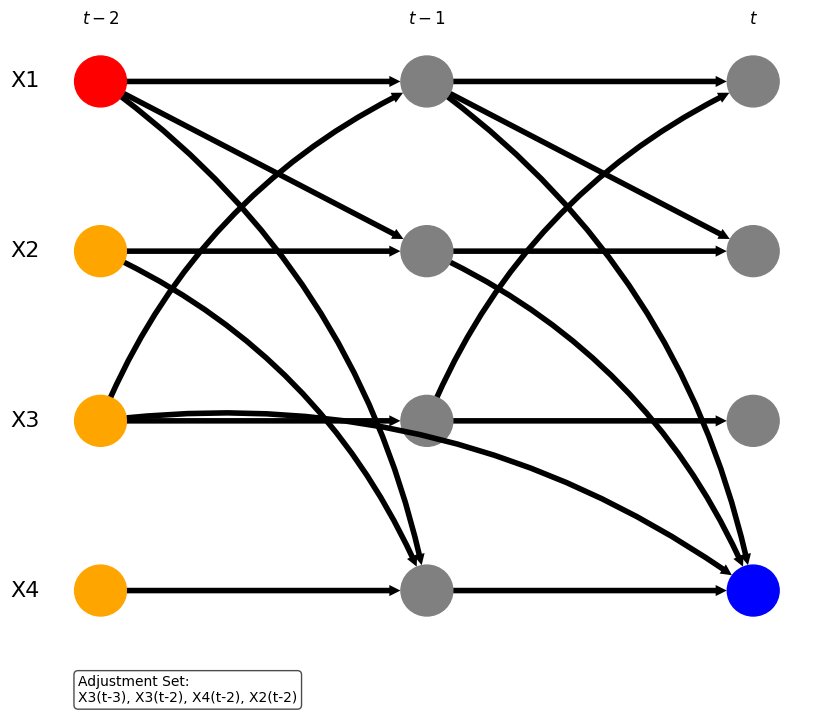

In [5]:
def plot_single_graph(graph, X, Y, adjustment_set=None, var_names=None, val_matrix=None, 
                     title=None, save_path=None, highlight_mediators=False):
    
    """
    Plot a single causal graph with the adjustment set highlighted.
    
    Parameters
    ----------
    graph : numpy.ndarray
        The causal graph to plot
    X : tuple
        Cause variable in format (var_idx, lag)
    Y : tuple
        Effect variable in format (var_idx, lag)
    adjustment_set : list, optional
        List of nodes in the adjustment set. If None, will attempt to calculate using CausalEffects.
    var_names : list, optional
        List of variable names. If None, defaults to X1, X2, etc.
    val_matrix : numpy.ndarray, optional
        Value matrix for edge colors (e.g., partial correlations)
    title : str, optional
        Plot title
    save_path : str, optional
        Path to save the figure
    highlight_mediators : bool, optional
        Whether to highlight mediator nodes in the graph
        
    Returns
    -------
    fig, ax
        The figure and axis objects
    """
    # Set default variable names if not provided
    if var_names is None:
        n_vars = graph.shape[0]
        var_names = [f'X{i+1}' for i in range(n_vars)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create special nodes highlighting
    special_nodes = {}
    special_nodes[X] = 'red'       # Cause node
    special_nodes[Y] = 'blue'      # Effect node

    if False:
        # Get adjustment set if not provided
        if adjustment_set is None:
            try:
                causal_effects = CausalEffects(
                    graph, 
                    graph_type='stationary_admg', 
                    X=[X], Y=[Y], 
                    S=None, 
                    hidden_variables=None, 
                    verbosity=0
                )
                
                # Check if there is a valid causal path
                has_path = causal_effects.check_XYS_paths()[0]
                
                if has_path:
                    adjustment_set = causal_effects.get_optimal_set()
                    
                    # Also highlight mediators if requested
                    if highlight_mediators and hasattr(causal_effects, 'M'):
                        for node in causal_effects.M:
                            special_nodes[node] = 'lightblue'  # Mediator nodes
                else:
                    adjustment_set = []
                    
            except Exception as e:
                print(f"Error calculating adjustment set: {e}")
                adjustment_set = []
    
    # Add adjustment set nodes to special nodes
    if adjustment_set:
        for node in adjustment_set:
            # Convert to tuple if it's a list
            node_tuple = tuple(node) if isinstance(node, list) else node
            special_nodes[node_tuple] = 'orange'  # Adjustment set nodes
    
    # Add node labels explaining colors for X and Y
    node_labels = {
        X: f"{var_names[X[0]]}(t{X[1]})\nCause",
        Y: f"{var_names[Y[0]]}(t{Y[1]})\nEffect"
    }
    
    # Plot graph with special nodes
    tp.plot_graph(
        graph=graph,
        var_names=var_names,
        val_matrix=val_matrix,
        fig_ax=(fig, ax),
        special_nodes=special_nodes,
        label_fontsize=16
    )
    
    # Add adjustment set as text below the graph
    if adjustment_set:
        formatted_set = [f"{var_names[node[0]]}(t{node[1]})" for node in adjustment_set]
        adj_text = "Adjustment Set:\n" + ", ".join(formatted_set)
        
        # Add text box with adjustment set
        ax.text(0.05, -0.05, adj_text, transform=ax.transAxes, 
                bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'),
                verticalalignment='top')
    
    # Set title
    if title:
        ax.set_title(title)
    
    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax

def plot_single_ts_graph(graph, X, Y, adjustment_set=None, var_names=None, val_matrix=None, 
                     title=None, save_path=None, highlight_mediators=False):
    
    """
    Plot a single causal graph with the adjustment set highlighted.
    
    Parameters
    ----------
    graph : numpy.ndarray
        The causal graph to plot
    X : tuple
        Cause variable in format (var_idx, lag)
    Y : tuple
        Effect variable in format (var_idx, lag)
    adjustment_set : list, optional
        List of nodes in the adjustment set. If None, will attempt to calculate using CausalEffects.
    var_names : list, optional
        List of variable names. If None, defaults to X1, X2, etc.
    val_matrix : numpy.ndarray, optional
        Value matrix for edge colors (e.g., partial correlations)
    title : str, optional
        Plot title
    save_path : str, optional
        Path to save the figure
    highlight_mediators : bool, optional
        Whether to highlight mediator nodes in the graph
        
    Returns
    -------
    fig, ax
        The figure and axis objects
    """
    # Set default variable names if not provided
    if var_names is None:
        n_vars = graph.shape[0]
        var_names = [f'X{i+1}' for i in range(n_vars)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create special nodes highlighting
    special_nodes = {}
    special_nodes[X] = 'red'       # Cause node
    special_nodes[Y] = 'blue'      # Effect node
    
    # Get adjustment set if not provided
    if adjustment_set is None:
        try:
            causal_effects = CausalEffects(
                graph, 
                graph_type='stationary_admg', 
                X=[X], Y=[Y], 
                S=None, 
                hidden_variables=None, 
                verbosity=0
            )
            
            # Check if there is a valid causal path
            has_path = causal_effects.check_XYS_paths()[0]
            
            if has_path:
                adjustment_set = causal_effects.get_optimal_set()
                
                # Also highlight mediators if requested
                if highlight_mediators and hasattr(causal_effects, 'M'):
                    for node in causal_effects.M:
                        special_nodes[node] = 'lightblue'  # Mediator nodes
            else:
                adjustment_set = []
                
        except Exception as e:
            print(f"Error calculating adjustment set: {e}")
            adjustment_set = []
    
    # Add adjustment set nodes to special nodes
    if adjustment_set:
        for node in adjustment_set:
            # Convert to tuple if it's a list
            node_tuple = tuple(node) if isinstance(node, list) else node
            special_nodes[node_tuple] = 'orange'  # Adjustment set nodes
    
    # Add node labels explaining colors for X and Y
    node_labels = {
        X: f"{var_names[X[0]]}(t{X[1]})\nCause",
        Y: f"{var_names[Y[0]]}(t{Y[1]})\nEffect"
    }
    
    # Plot graph with special nodes
    tp.plot_time_series_graph(
        graph=graph,
        var_names=var_names,
        #val_matrix=val_matrix,
        fig_ax=(fig, ax),
        special_nodes=special_nodes,
        label_fontsize=16
    )
    
    # Add adjustment set as text below the graph
    if adjustment_set:
        formatted_set = [f"{var_names[node[0]]}(t{node[1]})" for node in adjustment_set]
        adj_text = "Adjustment Set:\n" + ", ".join(formatted_set)
        
        # Add text box with adjustment set
        ax.text(0.05, -0.05, adj_text, transform=ax.transAxes, 
                bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'),
                verticalalignment='top')
    
    # Set title
    if title:
        ax.set_title(title)
    
    # Save if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, ax



# Example usage
if __name__ == "__main__":
    auto_coeff = 0.5
    cross_coeff=0.5
    linear_func = lambda x:x
    links = {
            0: [((0, -1), auto_coeff, linear_func), 
                ((2, -1), cross_coeff, linear_func)],
            1: [((1, -1), auto_coeff, linear_func), 
                ((0, -1), cross_coeff, linear_func)],
            2: [((2, -1), auto_coeff, linear_func)],       
            3: [((3, -1), auto_coeff, linear_func),
                ((0, -1), cross_coeff, linear_func), 
                ((1, -1), cross_coeff, linear_func), 
                ((2, -2), cross_coeff, linear_func)]
        }

    true_graph = PCMCI.get_graph_from_dict(links)
    # Replace with the actual folder path
    run_folder = "full_study_results_2025-04-03_15-39-17/T_study/T_1000"
    
    results = load_run_data(run_folder)
    
    # Get the effect pair from the loaded results
    effect_pair = next(iter(results['effects'].keys()))
    parts = effect_pair.split('_to_')
    x_parts = parts[0].split('_')
    y_parts = parts[1].split('_')
    
    X = (int(x_parts[0]), int(x_parts[1]))
    Y = (int(y_parts[0]), int(y_parts[1]))

    summarize_results(results)
    
    # 1. Plot single PCMCI graph with adjustment set
    pcmci_graph = results['pcmci_graph']
    pcmci_val_matrix = results.get('pcmci_val_matrix')

    bagged_graph = results['bagged_graph']
    bagged_val_matrix = results.get('bagged_val_matrix')
    
    adjustment_set = results['adjustment_sets'].get(effect_pair, {}).get('pcmci')
    var_names = results['dataframe'].var_names
    
    fig1, ax1 = plot_single_graph(
        graph=pcmci_graph,
        X=X,
        Y=Y,
        adjustment_set=adjustment_set,
        var_names=var_names,
        val_matrix=pcmci_val_matrix,
        title="",
        save_path="pcmci_single_graph.pdf"
    )
    plt.show()

    fig2, ax2 = plot_single_graph(
            graph=bagged_graph,
            X=X,
            Y=Y,
            adjustment_set=adjustment_set,
            var_names=var_names,
            val_matrix=pcmci_val_matrix,
            title="",
            save_path="bagged_single_graph.pdf"
        )
    plt.show()

    fig3, ax3 = plot_single_graph(
        graph=true_graph,
        X=X,
        Y=Y,
        adjustment_set=None,
        var_names=var_names,
        val_matrix=None,
        title="",
        save_path="true_single_graph.pdf"
    )

    fig4, ax4 = plot_single_ts_graph(
        graph=pcmci_graph,
        X=X,
        Y=Y,
        adjustment_set=adjustment_set,
        var_names=var_names,
        val_matrix=pcmci_val_matrix,
        title="",
        save_path="pcmci_single_ts_graph.pdf"
    )
    plt.show()

    fig5, ax5 = plot_single_ts_graph(
            graph=bagged_graph,
            X=X,
            Y=Y,
            adjustment_set=adjustment_set,
            var_names=var_names,
            val_matrix=pcmci_val_matrix,
            title="",
            save_path="bagged_single_ts_graph.pdf"
        )
    plt.show()

    fig6, ax6 = plot_single_ts_graph(
        graph=true_graph,
        X=X,
        Y=Y,
        adjustment_set=None,
        var_names=var_names,
        val_matrix=None,
        title="",
        save_path="true_single_ts_graph.pdf"
    )

    plt.show()